In [ ]:
!pip install pyspark

In [ ]:
import json
from pyspark.sql import SparkSession
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Mount Google Drive (Silently)
drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/cloud/csv_json-20251229-2143.csv'

# Initialize Spark Session
spark = SparkSession.builder.appName("OnlyPlants_MapReduce_Final").getOrCreate()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Temperature: MIN = 17.4 | MAX = 26.6
Humidity: MIN = 27.0 | MAX = 57.0
Soil: MIN = 8 | MAX = 100
Tempthreshold: MIN = 30.0 | MAX = 30.0
Humthreshold: MIN = 60.0 | MAX = 60.0


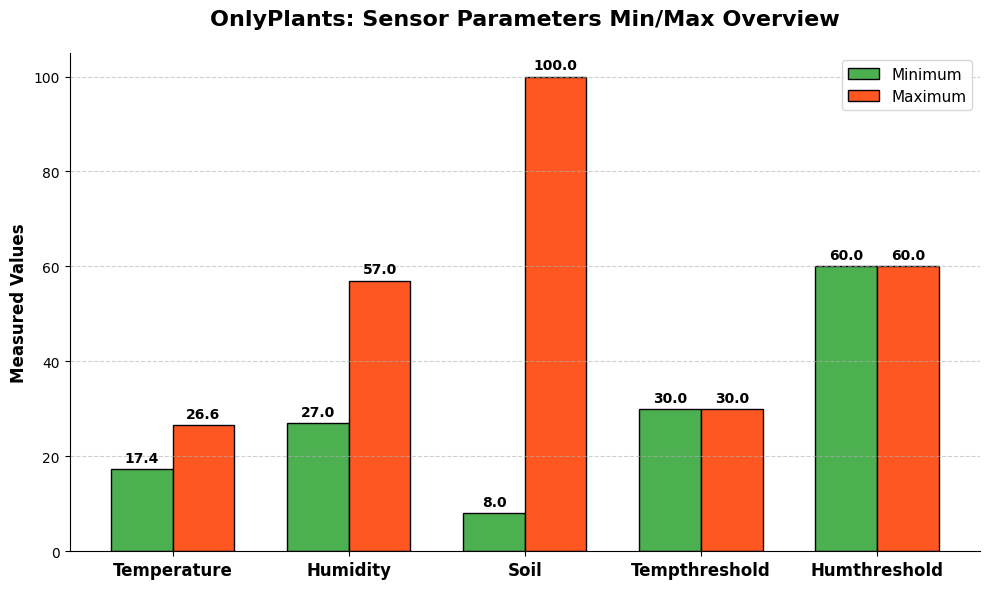

In [ ]:
if not os.path.exists(FILE_PATH):
    print(f"Error: File not found at path: {FILE_PATH}")
else:
    # Load the CSV data, handling the escaped quotes in the JSON column
    df = spark.read.csv(FILE_PATH, header=True, inferSchema=True, quote='"', escape='"')

    # --- Step 1: Map Stage ---
    def map_sensor_data(row):
        mapped_pairs = []
        try:
            val_string = row['value']
            if val_string:
                # Clean the JSON string before parsing
                clean_str = val_string.strip()
                if clean_str.startswith('"') and clean_str.endswith('"'):
                    clean_str = clean_str[1:-1]
                clean_str = clean_str.replace('""', '"')

                # Convert string to dictionary
                data_dict = json.loads(clean_str)

                for param, val in data_dict.items():
                    if isinstance(val, (int, float)):
                        mapped_pairs.append((param, (val, val)))
        except Exception as e:
            # Ignore broken rows
            pass

        return mapped_pairs

    mapped_rdd = df.rdd.flatMap(map_sensor_data)

    # --- Step 2: Reduce Stage ---
    def reduce_min_max(val1, val2):
        current_min = min(val1[0], val2[0])
        current_max = max(val1[1], val2[1])
        return (current_min, current_max)

    reduced_rdd = mapped_rdd.reduceByKey(reduce_min_max)
    results = reduced_rdd.collect()

    # --- Step 3: Output Minimum and Maximum only ---
    if not results:
        print("Warning: No valid data found to process.")
    else:
        sensor_names = []
        min_values = []
        max_values = []

        for sensor, (min_val, max_val) in results:
            print(f"{sensor.title()}: MIN = {min_val} | MAX = {max_val}")
            sensor_names.append(sensor)
            min_values.append(min_val)
            max_values.append(max_val)

        # --- Step 4: Create an interesting graph ---
        x_positions = np.arange(len(sensor_names))
        bar_width = 0.35

        fig, ax = plt.subplots(figsize=(10, 6))

        # Create aesthetic bars
        bars_min = ax.bar(x_positions - bar_width/2, min_values, bar_width, label='Minimum', color='#4CAF50', edgecolor='black')
        bars_max = ax.bar(x_positions + bar_width/2, max_values, bar_width, label='Maximum', color='#FF5722', edgecolor='black')

        # Formatting the chart
        ax.set_ylabel('Measured Values', fontsize=12, fontweight='bold')
        ax.set_title('OnlyPlants: Sensor Parameters Min/Max Overview', fontsize=16, fontweight='bold', pad=20)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([name.title() for name in sensor_names], fontsize=12, fontweight='bold')
        ax.legend(fontsize=11)

        # Function to add numeric labels on top of the bars
        def add_labels(bars):
            for bar in bars:
                height = bar.get_height()
                ax.annotate(f'{height:.1f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10, fontweight='bold')

        add_labels(bars_min)
        add_labels(bars_max)

        # Clean background details
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.grid(axis='y', linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()